# Construct MPO of radical pair system by [RadicalPy](https://github.com/Spin-Chemistry-Labs/radicalpy)

In this tutorial, one constructs MPO of radical pair system (two electron spins and a couple of nuclear spins under magnetic field) by using RadicalPy library.

In [1]:
try:
    import radicalpy
except ModuleNotFoundError:
    # remove uv if you are not using uv
    !uv pip install radicalpy --quiet
!uv pip show radicalpy

Using Python 3.12.2 environment at: /home/hinom/GitHub/PyMPO/.venv
Name: radicalpy
Version: 0.8.1
Location: /home/hinom/GitHub/PyMPO/.venv/lib/python3.12/site-packages
Requires: dot2tex, graphviz, importlib-resources, matplotlib, numpy, pint, scikit-learn, scipy, seaborn, sympy, tqdm
Required-by:


In [2]:
import numpy as np
import sympy
from pympo import (
    AssignManager,
    OpSite,
    SumOfProducts,
)
import matplotlib.pyplot as plt

import radicalpy as rp
from radicalpy.simulation import State

## Total Hamiltonian
$$
\hat{H}_{\text{total}} =
\hat{H}_{\text{Z}} + \hat{H}_{\text{H}} + \hat{H}_{\text{J}} + \hat{H}_{\text{D}}    
$$

## Define systems

In [6]:
flavin = rp.simulation.Molecule.fromisotopes(isotopes=["1H"], hfcs=[0.4])
Z = rp.simulation.Molecule.fromisotopes(isotopes=["14N"], hfcs=[0.5])
sim = rp.simulation.HilbertSimulation([flavin, Z])
sim

Number of electrons: 2
Number of nuclei: 2
Number of particles: 4
Multiplicities: [2, 2, 2, 3]
Magnetogyric ratios (mT): [-176085963.023, -176085963.023, 267522.18744, 19337.792]
Nuclei: [1H(267522187.44, 2, 0.4 <anisotropic not available>), 14N(19337792.0, 3, 0.5 <anisotropic not available>)]
Couplings: [0, 1]
HFCs (mT): [0.4 <anisotropic not available>, 0.5 <anisotropic not available>]

Now, one defines matrix product state (MPS) in the following order

(nuclei in `flavin`) $\to$ (electronic states $\{|T_{+}\rangle, |T_{0}\rangle, |S\rangle, |T_{-}\rangle\}$) $\to$ (neclei in `Z`)

## Extract one particle operator

RadicalPy provides variety of spin operators such as 

- $\hat{s}_x, \hat{s}_y, \hat{s}_z$ for radical singlet-triplet basis
- $\hat{I}_x, \hat{I}_y, \hat{I}_z$ for nuclear Zeeman basis

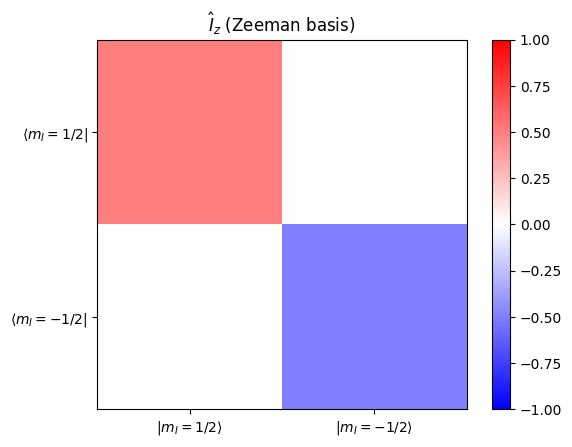

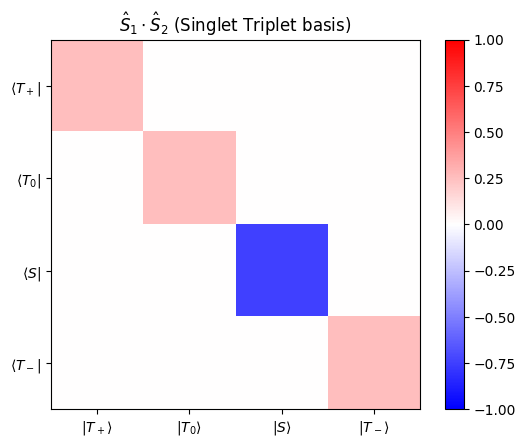

[E(-176085963023.0, 2, 0.0 <anisotropic not available>),
 E(-176085963023.0, 2, 0.0 <anisotropic not available>),
 1H(267522187.44, 2, 0.4 <anisotropic not available>),
 14N(19337792.0, 3, 0.5 <anisotropic not available>)]

In [11]:
Ix = [sim.particles[i].pauli['x'] for i in range(2, len(sim.particles))]
Iy = [sim.particles[i].pauli['y'] for i in range(2, len(sim.particles))]
Iz = [sim.particles[i].pauli['z'] for i in range(2, len(sim.particles))]

plt.imshow((Iz[0]).real, cmap='bwr', vmin=-1.0, vmax=1.0)
plt.title(r'$\hat{I}_z$ (Zeeman basis)')
plt.colorbar()
plt.xticks([0, 1], [r"$|m_I=1/2\rangle$", r"$|m_I=-1/2\rangle$"])
plt.yticks([0, 1], [r"$\langle m_I=1/2|$", r"$\langle m_I=-1/2|$"])
plt.show()

# Clear nuclei temporally
_nuclei_tmp0 = sim.molecules[0].nuclei
_nuclei_tmp1 = sim.molecules[1].nuclei
sim.molecules[0].nuclei = []
sim.molecules[1].nuclei = []

sx_0 = sim.spin_operator(0, 'x') # for Zeeman basis
sy_0 = sim.spin_operator(0, 'y') # for Zeeman basis
sz_0 = sim.spin_operator(0, 'z') # for Zeeman basis
sx_1 = sim.spin_operator(1, 'x') # for Zeeman basis
sy_1 = sim.spin_operator(1, 'y') # for Zeeman basis
sz_1 = sim.spin_operator(1, 'z') # for Zeeman basis

plt.imshow((sx_0 @ sx_1 + sy_0 @ sy_1 + sz_0 @ sz_1).real, cmap='bwr', vmin=-1.0, vmax=1.0)
plt.title(r'$\hat{S}_1\cdot \hat{S}_2$ (Singlet Triplet basis)')
plt.colorbar()
plt.xticks([0, 1, 2, 3], [r'$|T_+\rangle$', r'$|T_0\rangle$', r'$|S\rangle$', r'$|T_-\rangle$'])
plt.yticks([0, 1, 2, 3], [r'$\langle T_+|$', r'$\langle T_0 |$', r'$\langle S|$', r'$\langle T_- |$'])
plt.show()

# Reverse nuclei
sim.molecules[0].nuclei = _nuclei_tmp0
sim.molecules[1].nuclei = _nuclei_tmp1

sim.particles

## Define `OpSite` and coefficients

In [ ]:
A = 
J = 
D = 

## Hyperfine coupling Hamiltonian
$$
\hat{H}_{\text{H}} = \sum_i \sum_j \hat{S}_i\cdot A_{ij}\cdot \hat{I}_{ij}
= \sum_i \sum_j \sum_{r\in\{x, y, z\}} A_{ij}\hat{S}_{r}^{(i)}\hat{I}_{r}^{(ij)}
$$

In [5]:
Hz = SumOfProducts()